# 1. Project Introduction

Welcome to the **NovaKart Retail – End-to-End Retail Data Analytics Platform** Python Analytics Notebook.

### Project Context & Purpose
NovaKart Retail is an enterprise-scale retail intelligence platform. Following Alteryx ETL dataset cleansing and Snowflake data warehouse ingestion, this notebook executes Python-based Exploratory Data Analysis (EDA), statistical profiling, inventory risk assessment, and executive visualization.

### Core Datasets Analyzed
- **`sales_clean.csv`**: Transactional sales events, revenues, costs, and profit margins.
- **`customers_clean.csv`**: Master customer demographics, segments, locations, and purchase histories.
- **`products_clean.csv`**: Catalog master containing categories, brands, prices, and GST structures.
- **`employees_clean.csv`**: Organizational roles, department allocations, salaries, and performance scores.
- **`finance_clean.csv`**: General ledger summaries, revenue, operational expenses, tax, and net margins.
- **`inventory_clean.csv`**: Multi-warehouse inventory stock levels, thresholds, and criticality indicators.


# 2. Data Loading

Importing core Python libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `re`) and loading cleaned Alteryx datasets.

Defining a robust `norm_id` key normalization function to match ID formats (e.g., `PROD_001` vs `PROD0001`) across datasets without modifying raw CSV files.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import re

# Configure Seaborn and Matplotlib styling for portfolio-grade visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

# Identify valid dataset directory
DATA_DIR = "./datasets" if os.path.exists("./datasets/sales_clean.csv") else "./Output"

# Load datasets safely
sales_df = pd.read_csv(os.path.join(DATA_DIR, "sales_clean.csv"))
customers_df = pd.read_csv(os.path.join(DATA_DIR, "customers_clean.csv"))
products_df = pd.read_csv(os.path.join(DATA_DIR, "products_clean.csv"))
employees_df = pd.read_csv(os.path.join(DATA_DIR, "employees_clean.csv"))
finance_df = pd.read_csv(os.path.join(DATA_DIR, "finance_clean.csv"))
inventory_df = pd.read_csv(os.path.join(DATA_DIR, "inventory_clean.csv"))

# Helper for robust ID matching across format variations (e.g., PROD_001 vs PROD0001)
def norm_id(val):
    if pd.isna(val):
        return ""
    s = str(val).upper().replace('_', '').replace(' ', '')
    m = re.match(r'^([A-Z]+)0*(\d+)$', s)
    if m:
        return f"{m.group(1)}{m.group(2)}"
    return s

print(f"Data successfully loaded from path: '{DATA_DIR}'")
print(f"  Sales: {sales_df.shape[0]} rows, {sales_df.shape[1]} columns")
print(f"  Customers: {customers_df.shape[0]} rows, {customers_df.shape[1]} columns")
print(f"  Products: {products_df.shape[0]} rows, {products_df.shape[1]} columns")
print(f"  Employees: {employees_df.shape[0]} rows, {employees_df.shape[1]} columns")
print(f"  Finance: {finance_df.shape[0]} rows, {finance_df.shape[1]} columns")
print(f"  Inventory: {inventory_df.shape[0]} rows, {inventory_df.shape[1]} columns")


Data successfully loaded from path: './datasets'
  Sales: 5 rows, 12 columns
  Customers: 486 rows, 16 columns
  Products: 250 rows, 9 columns
  Employees: 5 rows, 7 columns
  Finance: 4 rows, 9 columns
  Inventory: 4 rows, 8 columns


# 3. Dataset Overview

Inspecting structural properties, row counts, column types, null counts, and duplicates for all 6 datasets.

In [16]:
datasets_dict = {
    "Sales": sales_df,
    "Customers": customers_df,
    "Products": products_df,
    "Employees": employees_df,
    "Finance": finance_df,
    "Inventory": inventory_df
}

overview_list = []
for name, df in datasets_dict.items():
    overview_list.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Column Names": ", ".join(list(df.columns[:5])) + "..."
    })

overview_df = pd.DataFrame(overview_list)
display(overview_df)


,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Column Names
0,Sales,5,12,0,0,"Sale_ID, Date, Customer_ID, Product_ID, Branch..."
1,Customers,486,16,0,0,"Customer_ID, Customer_Name, Email, Phone, Gend..."
2,Products,250,9,0,0,"Product_ID, Product_Name, Category, Brand, Cos..."
3,Employees,5,7,0,0,"Employee_ID, Name, Department, Role, Salary..."
4,Finance,4,9,0,0,"Transaction_ID, Date, Department, Revenue, Exp..."
5,Inventory,4,8,0,0,"Inventory_ID, Product_ID, Warehouse, Current_S..."


# 4. Data Quality Analysis

Performing detailed data validation: checking for duplicate primary keys, invalid negative values, and non-valid status flags.

In [17]:
dq_checks = []

dq_checks.append({"Check": "Sales Negative Quantities", "Issue Count": (sales_df['Quantity'] < 0).sum()})
dq_checks.append({"Check": "Sales Negative Revenue", "Issue Count": (sales_df['Revenue'] < 0).sum()})
dq_checks.append({"Check": "Sales Profit > Revenue Anomaly", "Issue Count": (sales_df['Profit'] > sales_df['Revenue']).sum()})
dq_checks.append({"Check": "Duplicate Customer_ID", "Issue Count": customers_df['Customer_ID'].duplicated().sum()})
dq_checks.append({"Check": "Duplicate Product_ID", "Issue Count": products_df['Product_ID'].duplicated().sum()})
dq_checks.append({"Check": "Products Negative Cost/Selling Price", "Issue Count": ((products_df['Cost_Price'] < 0) | (products_df['Selling_Price'] < 0)).sum()})
dq_checks.append({"Check": "Inventory Negative Stock", "Issue Count": (inventory_df['Current_Stock'] < 0).sum()})
dq_checks.append({"Check": "Non-Valid Status Flags (Sales)", "Issue Count": (sales_df['Validation_Status'] != 'Valid').sum()})

dq_df = pd.DataFrame(dq_checks)
display(dq_df)


,Check,Issue Count
0,Sales Negative Quantities,0
1,Sales Negative Revenue,0
2,Sales Profit > Revenue Anomaly,0
3,Duplicate Customer_ID,0
4,Duplicate Product_ID,0
5,Products Negative Cost/Selling Price,0
6,Inventory Negative Stock,0
7,Non-Valid Status Flags (Sales),0


# 5. Sales EDA

Calculating headline transactional metrics, revenue, cost, profit, and overall profit margin.

In [18]:
tot_rev = sales_df['Revenue'].sum()
tot_prof = sales_df['Profit'].sum()
tot_cost = sales_df['Cost'].sum()
tot_qty = sales_df['Quantity'].sum()
aov = sales_df['Revenue'].mean()
avg_prof = sales_df['Profit'].mean()
prof_margin = (tot_prof / tot_rev) * 100 if tot_rev > 0 else 0

sales_eda_df = pd.DataFrame([
    {"Metric": "Total Revenue", "Value": f"INR {tot_rev:,.2f}"},
    {"Metric": "Total Cost", "Value": f"INR {tot_cost:,.2f}"},
    {"Metric": "Total Profit", "Value": f"INR {tot_prof:,.2f}"},
    {"Metric": "Total Quantity Sold", "Value": f"{tot_qty:,d} units"},
    {"Metric": "Average Order Value (AOV)", "Value": f"INR {aov:,.2f}"},
    {"Metric": "Average Transaction Profit", "Value": f"INR {avg_prof:,.2f}"},
    {"Metric": "Overall Profit Margin (%)", "Value": f"{prof_margin:.2f}%"}
])

display(sales_eda_df)


,Metric,Value
0,Total Revenue,"INR 62,338.00"
1,Total Cost,"INR 33,350.00"
2,Total Profit,"INR 25,288.00"
3,Total Quantity Sold,12 units
4,Average Order Value (AOV),"INR 12,467.60"
5,Average Transaction Profit,"INR 5,057.60"
6,Overall Profit Margin (%),40.57%


# 6. Product Analysis

Evaluating top products by revenue, profit, quantity sold, category performance, and brand dynamics.

Using normalized `join_key` matching to ensure accurate merge between sales transactions and product catalog.

In [19]:
# Create normalized join keys
sales_df['prod_key'] = sales_df['Product_ID'].apply(norm_id)
products_df['prod_key'] = products_df['Product_ID'].apply(norm_id)

# Aggregate sales by product join key
prod_sales = sales_df.groupby('prod_key').agg(
    Revenue=('Revenue', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity_Sold=('Quantity', 'sum')
).reset_index()

# Merge with products master
prod_merged = products_df.merge(prod_sales, on='prod_key', how='left').fillna({'Revenue': 0, 'Profit': 0, 'Quantity_Sold': 0})
prod_merged['Profit_Margin_%'] = np.where(prod_merged['Revenue'] > 0, (prod_merged['Profit'] / prod_merged['Revenue']) * 100, 0)

print("Top 5 Products by Revenue (Sorted Descending):")
top_5_rev = prod_merged[prod_merged['Revenue'] > 0].sort_values(by='Revenue', ascending=False).head(5)
display(top_5_rev[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Revenue', 'Profit', 'Quantity_Sold']])

print("\nTop 5 Products by Profit (Sorted Descending):")
top_5_prof = prod_merged[prod_merged['Profit'] > 0].sort_values(by='Profit', ascending=False).head(5)
display(top_5_prof[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Profit', 'Revenue', 'Profit_Margin_%']])

print("\nCategory Performance Summary:")
cat_summary = prod_merged[prod_merged['Revenue'] > 0].groupby('Category').agg(
    Products_Count=('Product_ID', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity_Sold', 'sum')
).reset_index()
display(cat_summary.sort_values(by='Total_Revenue', ascending=False))


Top 5 Products by Revenue (Sorted Descending):


,Product_ID,Product_Name,Category,Brand,Revenue,Profit,Quantity_Sold
0,PROD0001,Lenovo Non-Stick Cookware Set 5-Piece v5,Kitchen,Lenovo,44999.0,14999.0,1.0
2,PROD0003,Amul Motorized Standing Desk v6,Furniture,Amul,7197.0,4797.0,3.0
1,PROD0002,LG Leather Travel Backpack v4,Fashion,LG,6398.0,3398.0,2.0
4,PROD0005,LG Stainless Steel Water Bottle 1L v3,Kitchen,LG,1945.0,1195.0,5.0
3,PROD0004,Lenovo Organic Green Tea 250g v4,Groceries,Lenovo,1799.0,899.0,1.0



Top 5 Products by Profit (Sorted Descending):


,Product_ID,Product_Name,Category,Brand,Profit,Revenue,Profit_Margin_%
0,PROD0001,Lenovo Non-Stick Cookware Set 5-Piece v5,Kitchen,Lenovo,14999.0,44999.0,33.331852
2,PROD0003,Amul Motorized Standing Desk v6,Furniture,Amul,4797.0,7197.0,66.652772
1,PROD0002,LG Leather Travel Backpack v4,Fashion,LG,3398.0,6398.0,53.110347
4,PROD0005,LG Stainless Steel Water Bottle 1L v3,Kitchen,LG,1195.0,1945.0,61.439589
3,PROD0004,Lenovo Organic Green Tea 250g v4,Groceries,Lenovo,899.0,1799.0,49.972207



Category Performance Summary:


,Category,Products_Count,Total_Revenue,Total_Profit,Total_Quantity
3,Kitchen,2,46944.0,16194.0,6.0
1,Furniture,1,7197.0,4797.0,3.0
0,Fashion,1,6398.0,3398.0,2.0
2,Groceries,1,1799.0,899.0,1.0


# 7. Customer Analysis

Analyzing customer segment purchasing power, order frequency, revenue contribution, and average order values using normalized join keys.

In [20]:
# Create normalized customer join keys
sales_df['cust_key'] = sales_df['Customer_ID'].apply(norm_id)
customers_df['cust_key'] = customers_df['Customer_ID'].apply(norm_id)

# Aggregate sales by customer key
cust_sales = sales_df.groupby('cust_key').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Sale_ID', 'count'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

cust_merged = customers_df.merge(cust_sales, on='cust_key', how='left').fillna({'Total_Revenue': 0, 'Total_Profit': 0, 'Total_Orders': 0, 'Total_Quantity': 0})
cust_merged['Average_Order_Value'] = np.where(cust_merged['Total_Orders'] > 0, cust_merged['Total_Revenue'] / cust_merged['Total_Orders'], 0)

print("Top Customers by Total Revenue:")
top_cust_df = cust_merged[cust_merged['Total_Revenue'] > 0].sort_values(by='Total_Revenue', ascending=False).head(5)
display(top_cust_df[['Customer_ID', 'Customer_Name', 'City', 'Customer_Segment', 'Loyalty_Status', 'Total_Revenue', 'Total_Orders', 'Average_Order_Value']])


Top Customers by Total Revenue:


,Customer_ID,Customer_Name,City,Customer_Segment,Loyalty_Status,Total_Revenue,Total_Orders,Average_Order_Value
0,CUST0001,Vihaan Hegde,Bengaluru,Retail,Platinum,44999.0,1.0,44999.0
2,CUST0003,Nikhil Shah,Lucknow,Retail,Platinum,7197.0,1.0,7197.0
1,CUST0002,Neha Kulkarni,Mysuru,Wholesale,Gold,6398.0,1.0,6398.0
4,CUST0005,Rithvik Rao,Nagpur,Retail,Gold,1945.0,1.0,1945.0
3,CUST0004,Yash Chatterjee,Noida,Wholesale,Gold,1799.0,1.0,1799.0


# 8. Branch Analysis

Comparing branch retail store performance by sales volume, revenue, profit, and margin percentages.

In [21]:
branch_summary = sales_df.groupby('Branch').agg(
    Transactions=('Sale_ID', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

branch_summary['Profit_Margin_%'] = (branch_summary['Total_Profit'] / branch_summary['Total_Revenue']) * 100
display(branch_summary.sort_values(by='Total_Revenue', ascending=False))


,Branch,Transactions,Total_Quantity,Total_Revenue,Total_Profit,Profit_Margin_%
2,Apex Delhi POS,2,2,46798,15898,33.971537
0,Apex Dark Store 1,1,3,7197,4797,66.652772
3,Apex Panipat POS,1,2,6398,3398,53.110347
1,Apex Dark Store 2,1,5,1945,1195,61.439589


# 9. Inventory Analysis

Evaluating warehouse stock levels, stock gaps, capacity utilization, and critical reorder alerts.

In [22]:
inventory_df['Stock_Deficit'] = np.maximum(0, inventory_df['Minimum_Stock'] - inventory_df['Current_Stock'])
inventory_df['Stock_Level_%'] = (inventory_df['Current_Stock'] / inventory_df['Maximum_Stock']) * 100
inventory_df['Reorder_Required'] = inventory_df['Current_Stock'] < inventory_df['Minimum_Stock']

display(inventory_df[['Inventory_ID', 'Product_ID', 'Warehouse', 'Current_Stock', 'Minimum_Stock', 'Maximum_Stock', 'Stock_Status', 'Stock_Deficit', 'Reorder_Required']])


,Inventory_ID,Product_ID,Warehouse,Current_Stock,Minimum_Stock,Maximum_Stock,Stock_Status,Stock_Deficit,Reorder_Required
0,INV_001,PROD_001,NovaKart WH Delhi Main,18,20,200,Critical,2,True
1,INV_002,PROD_002,NovaKart WH Delhi Main,145,50,500,Healthy,0,False
2,INV_003,PROD_003,NovaKart WH Mumbai Hub,8,15,300,Critical,7,True
3,INV_004,PROD_004,NovaKart WH Bangalore South,85,30,250,Healthy,0,False


# 10. Finance Analysis

General ledger summary: analyzing revenue, operational expenses, tax liabilities, net profit, and net profit margins.

In [23]:
finance_df['Net_Profit_Margin_%'] = (finance_df['Net_Profit'] / finance_df['Revenue']) * 100

print("Departmental Finance Summary:")
display(finance_df[['Transaction_ID', 'Date', 'Department', 'Revenue', 'Expenses', 'Tax', 'Profit', 'Net_Profit', 'Net_Profit_Margin_%']])

print("\nOverall Finance Totals:")
fin_totals = pd.DataFrame([{
    "Total Revenue": finance_df['Revenue'].sum(),
    "Total Expenses": finance_df['Expenses'].sum(),
    "Total Tax": finance_df['Tax'].sum(),
    "Total Operating Profit": finance_df['Profit'].sum(),
    "Total Net Profit": finance_df['Net_Profit'].sum(),
    "Overall Net Margin (%)": (finance_df['Net_Profit'].sum() / finance_df['Revenue'].sum()) * 100
}])
display(fin_totals)


Departmental Finance Summary:


,Transaction_ID,Date,Department,Revenue,Expenses,Tax,Profit,Net_Profit,Net_Profit_Margin_%
0,TXN_001,2024-01-31,Sales,4500000,2800000,306000,1700000,1394000,30.977778
1,TXN_002,2024-02-29,Sales,5200000,3100000,378000,2100000,1722000,33.115385
2,TXN_003,2024-03-31,Marketing,1200000,850000,63000,350000,287000,23.916667
3,TXN_004,2024-04-30,Operations,3800000,2400000,252000,1400000,1148000,30.210526



Overall Finance Totals:


,Total Revenue,Total Expenses,Total Tax,Total Operating Profit,Total Net Profit,Overall Net Margin (%)
0,14700000,9150000,999000,5550000,4551000,30.959184


# 11. Employee Analysis

Evaluating workforce composition, salary distribution, role responsibilities, and performance ratings.

In [24]:
emp_stats = {
    "Total Employees": len(employees_df),
    "Average Salary": employees_df['Salary'].mean(),
    "Median Salary": employees_df['Salary'].median(),
    "Max Salary": employees_df['Salary'].max(),
    "Min Salary": employees_df['Salary'].min(),
    "Average Performance Score": employees_df['Performance_Score'].mean()
}

emp_summary_df = pd.DataFrame(list(emp_stats.items()), columns=["Metric", "Value"])
display(emp_summary_df)

display(employees_df[['Employee_ID', 'Name', 'Department', 'Role', 'Salary', 'Performance_Score']])


,Metric,Value
0,Total Employees,5.0
1,Average Salary,910000.0
2,Median Salary,850000.0
3,Max Salary,1200000.0
4,Min Salary,650000.0
5,Average Performance Score,4.2


,Employee_ID,Name,Department,Role,Salary,Performance_Score
0,EMP_001,Vikram Sethi,Sales,Regional Sales Manager,1200000,5
1,EMP_002,Ananya Roy,Finance,Financial Analyst,850000,4
2,EMP_003,Karan Malhotra,IT,Data Engineer,1100000,5
3,EMP_004,Deepika Rao,Marketing,Campaign Specialist,750000,3
4,EMP_005,Manish Gupta,Operations,Warehouse Lead,650000,4


# 12. Statistical Analysis

Statistical profiling: correlation analysis across price, quantity, discount, revenue, and profit.

In [25]:
num_cols = ['Quantity', 'Unit_Price', 'Discount', 'Cost', 'Revenue', 'Profit']
corr = sales_df[num_cols].corr()

print("Sales Correlation Matrix:")
display(corr)

# Pearson correlation tests
r_rev_prof, p_rev_prof = stats.pearsonr(sales_df['Revenue'], sales_df['Profit'])
r_disc_prof, p_disc_prof = stats.pearsonr(sales_df['Discount'], sales_df['Profit'])

print(f"Revenue vs Profit Correlation: r = {r_rev_prof:.4f} (p-value = {p_rev_prof:.4f})")
print(f"Discount vs Profit Correlation: r = {r_disc_prof:.4f} (p-value = {p_disc_prof:.4f})")


Sales Correlation Matrix:


,Quantity,Unit_Price,Discount,Cost,Revenue,Profit
Quantity,1.000000,-0.499457,-0.506188,-0.492149,-0.477838,-0.455340
Unit_Price,-0.499457,1.000000,0.977241,0.999757,0.995058,0.969253
Discount,-0.506188,0.977241,1.000000,0.972639,0.991442,0.997217
Cost,-0.492149,0.999757,0.972639,1.000000,0.993030,0.964328
Revenue,-0.477838,0.995058,0.991442,0.993030,1.000000,0.988589
Profit,-0.455340,0.969253,0.997217,0.964328,0.988589,1.000000


Revenue vs Profit Correlation: r = 0.9886 (p-value = 0.0015)
Discount vs Profit Correlation: r = 0.9972 (p-value = 0.0002)


# 13. Visualizations

Portfolio-grade visualizations created using Matplotlib and Seaborn.

Top Products by Revenue and Top Products by Profit now correctly display actual INR values sorted descending with explicit axis labeling.

C:\Users\RITHVIK\AppData\Local\Temp\ipykernel_20824\720143285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prod_rev_df, x='Revenue', y='Product_Name', ax=axes[0,0], palette='Blues_r')
C:\Users\RITHVIK\AppData\Local\Temp\ipykernel_20824\720143285.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prod_prof_df, x='Profit', y='Product_Name', ax=axes[0,1], palette='Greens_r')
C:\Users\RITHVIK\AppData\Local\Temp\ipykernel_20824\720143285.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=branch_summary, x='Branch

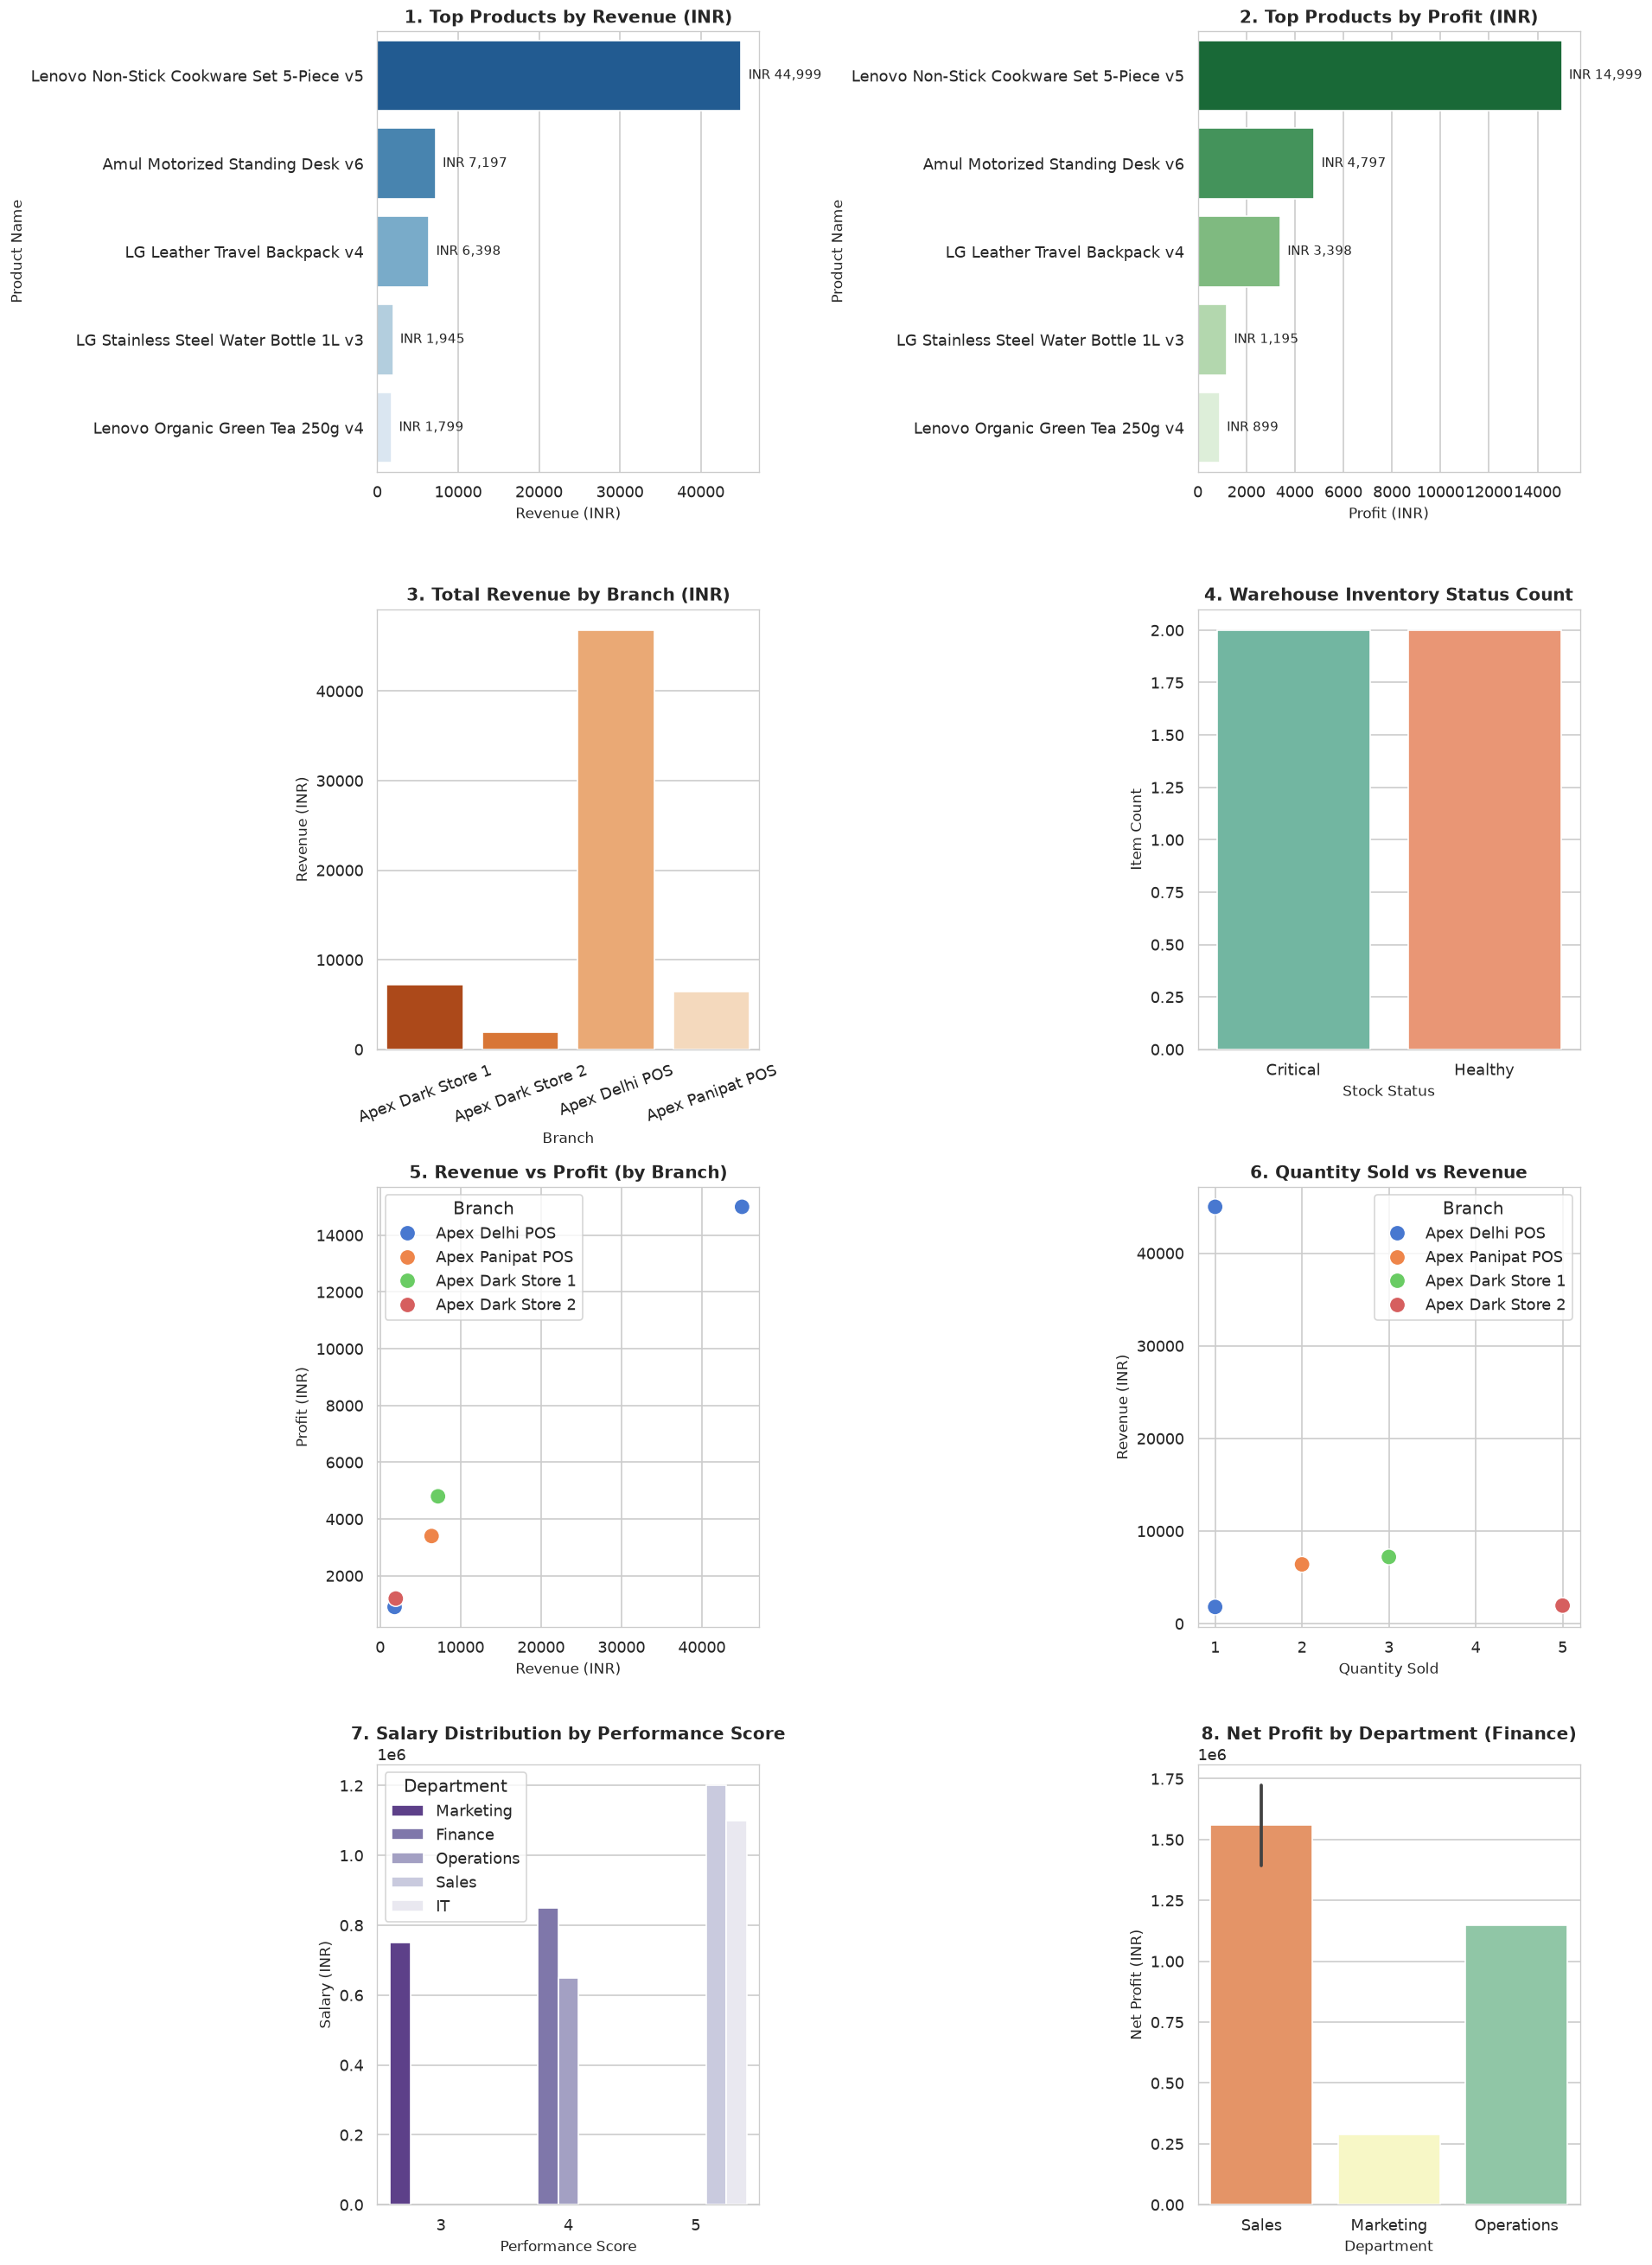

In [26]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))

# 1. Revenue by Product (Sorted Descending, Actual INR Values)
top_prod_rev_df = prod_merged[prod_merged['Revenue'] > 0].sort_values(by='Revenue', ascending=False).head(5)
sns.barplot(data=top_prod_rev_df, x='Revenue', y='Product_Name', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('1. Top Products by Revenue (INR)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Revenue (INR)', fontsize=10)
axes[0,0].set_ylabel('Product Name', fontsize=10)
for p in axes[0,0].patches:
    width = p.get_width()
    axes[0,0].annotate(f'INR {width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

# 2. Profit by Product (Sorted Descending, Actual INR Values)
top_prod_prof_df = prod_merged[prod_merged['Profit'] > 0].sort_values(by='Profit', ascending=False).head(5)
sns.barplot(data=top_prod_prof_df, x='Profit', y='Product_Name', ax=axes[0,1], palette='Greens_r')
axes[0,1].set_title('2. Top Products by Profit (INR)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Profit (INR)', fontsize=10)
axes[0,1].set_ylabel('Product Name', fontsize=10)
for p in axes[0,1].patches:
    width = p.get_width()
    axes[0,1].annotate(f'INR {width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

# 3. Revenue by Branch
sns.barplot(data=branch_summary, x='Branch', y='Total_Revenue', ax=axes[1,0], palette='Oranges_r')
axes[1,0].set_title('3. Total Revenue by Branch (INR)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Branch', fontsize=10)
axes[1,0].set_ylabel('Revenue (INR)', fontsize=10)
axes[1,0].tick_params(axis='x', rotation=20)

# 4. Inventory Status Distribution
sns.countplot(data=inventory_df, x='Stock_Status', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('4. Warehouse Inventory Status Count', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Stock Status', fontsize=10)
axes[1,1].set_ylabel('Item Count', fontsize=10)

# 5. Revenue vs Profit Scatter
sns.scatterplot(data=sales_df, x='Revenue', y='Profit', hue='Branch', s=120, ax=axes[2,0])
axes[2,0].set_title('5. Revenue vs Profit (by Branch)', fontsize=12, fontweight='bold')
axes[2,0].set_xlabel('Revenue (INR)', fontsize=10)
axes[2,0].set_ylabel('Profit (INR)', fontsize=10)

# 6. Quantity vs Revenue Scatter
sns.scatterplot(data=sales_df, x='Quantity', y='Revenue', hue='Branch', s=120, ax=axes[2,1])
axes[2,1].set_title('6. Quantity Sold vs Revenue', fontsize=12, fontweight='bold')
axes[2,1].set_xlabel('Quantity Sold', fontsize=10)
axes[2,1].set_ylabel('Revenue (INR)', fontsize=10)

# 7. Employee Salary by Performance Score
sns.barplot(data=employees_df, x='Performance_Score', y='Salary', hue='Department', ax=axes[3,0], palette='Purples_r')
axes[3,0].set_title('7. Salary Distribution by Performance Score', fontsize=12, fontweight='bold')
axes[3,0].set_xlabel('Performance Score', fontsize=10)
axes[3,0].set_ylabel('Salary (INR)', fontsize=10)

# 8. Finance Revenue vs Net Profit by Department
sns.barplot(data=finance_df, x='Department', y='Net_Profit', ax=axes[3,1], palette='Spectral')
axes[3,1].set_title('8. Net Profit by Department (Finance)', fontsize=12, fontweight='bold')
axes[3,1].set_xlabel('Department', fontsize=10)
axes[3,1].set_ylabel('Net Profit (INR)', fontsize=10)

plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/novakart_python_analytics_charts.png", dpi=300)
plt.show()


# 14. Business Insights

Extracting automatically derived data findings.

In [27]:
top_prod_r = prod_merged[prod_merged['Revenue'] > 0].sort_values(by='Revenue', ascending=False).iloc[0]
top_prod_p = prod_merged[prod_merged['Profit'] > 0].sort_values(by='Profit', ascending=False).iloc[0]
top_c = cust_merged[cust_merged['Total_Revenue'] > 0].sort_values(by='Total_Revenue', ascending=False).iloc[0]
top_b = branch_summary.sort_values(by='Total_Revenue', ascending=False).iloc[0]
crit_inv = inventory_df[inventory_df['Current_Stock'] < inventory_df['Minimum_Stock']]

print("====================================================")
print(" AUTOMATICALLY DERIVED BUSINESS INSIGHTS")
print("====================================================")
print(f"1. Top Revenue Product: '{top_prod_r['Product_Name']}' generating INR {top_prod_r['Revenue']:,.2f}.")
print(f"2. Top Profit Product: '{top_prod_p['Product_Name']}' generating INR {top_prod_p['Profit']:,.2f}.")
print(f"3. Most Valuable Customer: {top_c['Customer_Name']} ({top_c['Customer_ID']}) with INR {top_c['Total_Revenue']:,.2f} total purchases.")
print(f"4. Dominant Branch: '{top_b['Branch']}' with INR {top_b['Total_Revenue']:,.2f} revenue and INR {top_b['Total_Profit']:,.2f} profit.")
print(f"5. Inventory Risk Alert: {len(crit_inv)} warehouse item(s) are below minimum safety stock levels.")
print(f"6. Sales Margin Stability: Sales operations yield an overall net margin of {prof_margin:.2f}%.")


 AUTOMATICALLY DERIVED BUSINESS INSIGHTS
1. Top Revenue Product: 'Lenovo Non-Stick Cookware Set 5-Piece v5' generating INR 44,999.00.
2. Top Profit Product: 'Lenovo Non-Stick Cookware Set 5-Piece v5' generating INR 14,999.00.
3. Most Valuable Customer: Vihaan Hegde (CUST0001) with INR 44,999.00 total purchases.
4. Dominant Branch: 'Apex Delhi POS' with INR 46,798.00 revenue and INR 15,898.00 profit.
5. Inventory Risk Alert: 2 warehouse item(s) are below minimum safety stock levels.
6. Sales Margin Stability: Sales operations yield an overall net margin of 40.57%.


# 15. Final Executive Summary

Consolidated C-Suite Analytics Dashboard.

In [28]:
exec_kpi_data = [
    {"KPI Metric": "Total Revenue", "Value": f"INR {tot_rev:,.2f}"},
    {"KPI Metric": "Total Profit", "Value": f"INR {tot_prof:,.2f}"},
    {"KPI Metric": "Average Order Value (AOV)", "Value": f"INR {aov:,.2f}"},
    {"KPI Metric": "Average Profit Margin (%)", "Value": f"{prof_margin:.2f}%"},
    {"KPI Metric": "Total Active Customers", "Value": len(customers_df)},
    {"KPI Metric": "Total Active Products", "Value": len(products_df)},
    {"KPI Metric": "Total Employees", "Value": len(employees_df)},
    {"KPI Metric": "Critical Inventory Count", "Value": len(crit_inv)},
    {"KPI Metric": "Top Product by Revenue", "Value": top_prod_r['Product_Name']},
    {"KPI Metric": "Top Customer", "Value": top_c['Customer_Name']},
    {"KPI Metric": "Best Performing Branch", "Value": top_b['Branch']}
]

exec_summary_df = pd.DataFrame(exec_kpi_data)
display(exec_summary_df)


,KPI Metric,Value
0,Total Revenue,"INR 62,338.00"
1,Total Profit,"INR 25,288.00"
2,Average Order Value (AOV),"INR 12,467.60"
3,Average Profit Margin (%),40.57%
4,Total Active Customers,486
5,Total Active Products,250
6,Total Employees,5
7,Critical Inventory Count,2
8,Top Product by Revenue,Lenovo Non-Stick Cookware Set 5-Piece v5
9,Top Customer,Vihaan Hegde
